# Data Preprocessing and Visualization part

In [53]:
# Reading the Precipitation dataset

import xarray as xr
# load dataset
ds = xr.open_dataset(r"D:\IITB Mini_projects\GNR644_drought\Rainfall_Resample_Cropped.nc")

print("DATASET OVERVIEW:")
print(ds)

DATASET OVERVIEW:
<xarray.Dataset> Size: 6MB
Dimensions:           (time: 297, lat: 67, lon: 73)
Coordinates:
  * time              (time) datetime64[ns] 2kB 2000-01-01 ... 2024-09-01
  * lat               (lat) float64 536B 8.25 8.5 8.75 9.0 ... 24.25 24.5 24.75
  * lon               (lon) float64 584B 72.75 73.0 73.25 ... 90.25 90.5 90.75
Data variables:
    spatial_ref       int64 8B ...
    satellite_precip  (time, lat, lon) float32 6MB ...


In [54]:
print("VARIABLES:")
print(list(ds.data_vars))

VARIABLES:
['spatial_ref', 'satellite_precip']


In [55]:
# Check Dimensions & Size

print("DIMENSIONS:")
print(ds.dims)

print("\nSHAPE:")
for var in ds.data_vars:
    print(var, ds[var].shape)

DIMENSIONS:
FrozenMappingWarningOnValuesAccess({'time': 297, 'lat': 67, 'lon': 73})

SHAPE:
spatial_ref ()
satellite_precip (297, 67, 73)


In [56]:
# Time Range

time = ds['time'] # MONTHLY PREPICITATION DATA - START: 2000 JAN;     END: 2024 SEPTEMBER
print("TIME RANGE:")
print("Start:", str(time.min().values))
print("End:", str(time.max().values))

TIME RANGE:
Start: 2000-01-01T00:00:00.000000000
End: 2024-09-01T00:00:00.000000000


In [57]:
# Resolution Check (Daily / Monthly)
import pandas as pd

time_diff = pd.Series(time.values).diff().value_counts()
print("TIME RESOLUTION:")
print(time_diff.head())

TIME RESOLUTION:
31 days    173
30 days     98
28 days     18
29 days      7
Name: count, dtype: int64


In [58]:
# Spatial Resolution
import numpy as np
lat = ds['lat']
lon = ds['lon']
lat_res = float(np.abs(lat[1] - lat[0]))
lon_res = float(np.abs(lon[1] - lon[0]))

print("Spatial Resolution:")
print(f"Latitude Resolution: {lat_res} degrees")
print(f"Longitude Resolution: {lon_res} degrees")

Spatial Resolution:
Latitude Resolution: 0.25 degrees
Longitude Resolution: 0.25 degrees


In [59]:
# VISUALIZATION

import matplotlib.pyplot as plt
rain = ds['satellite_precip']

# spatial average
rain_mean = rain.mean(dim=['lat', 'lon'])

In [60]:
df = rain_mean.to_dataframe(name='Rainfall').reset_index() # converting to pandas

# Year and Month
df['Year'] = df['time'].dt.year
df['Month'] = df['time'].dt.month

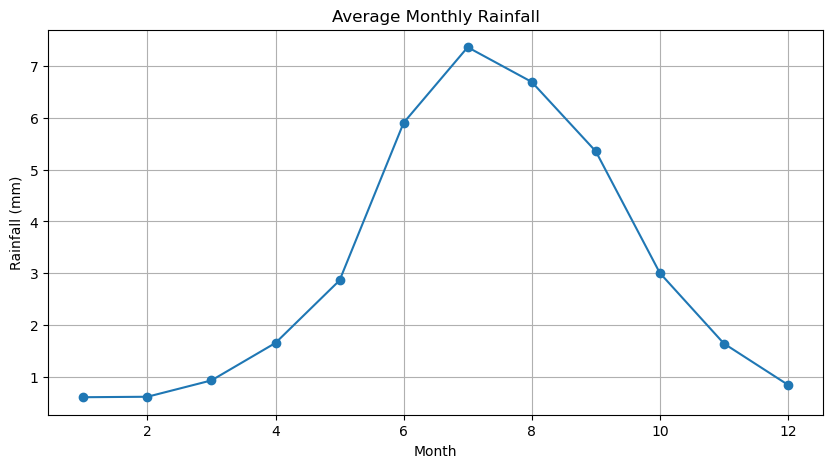

In [61]:
# Monthly average
monthly_avg = df.groupby('Month')['Rainfall'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.grid()
plt.show()

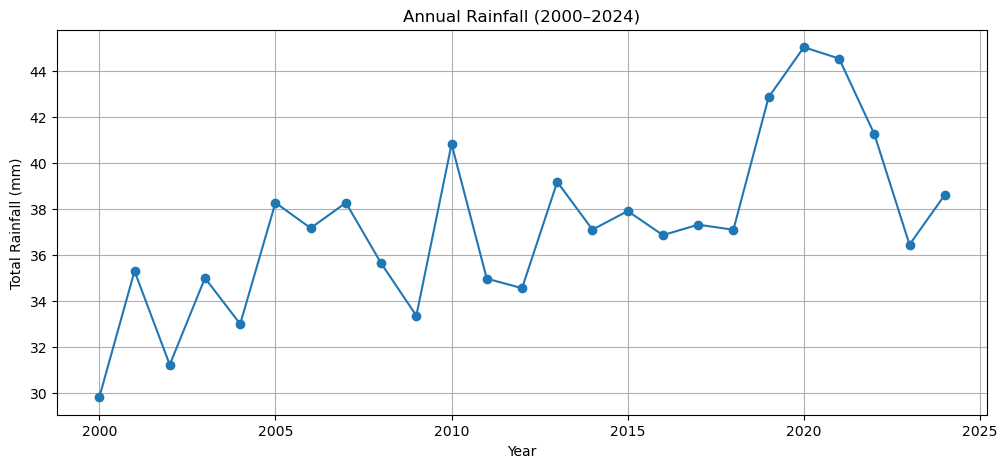

In [62]:
# Annual rainfall
annual_rain = df.groupby('Year')['Rainfall'].sum()
plt.figure(figsize=(12,5))
plt.plot(annual_rain.index, annual_rain.values, marker='o')
plt.title("Annual Rainfall (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Total Rainfall (mm)")
plt.grid()
plt.show()

In [63]:
# Saving the outputs: 
monthly_avg.to_csv("monthly_climatology.csv")
annual_rain.to_csv("annual_rainfall.csv")
print("'monthly_climatology.csv' was saved...")
print("'annual_rainfall.csv' was saved...")

'monthly_climatology.csv' was saved...
'annual_rainfall.csv' was saved...


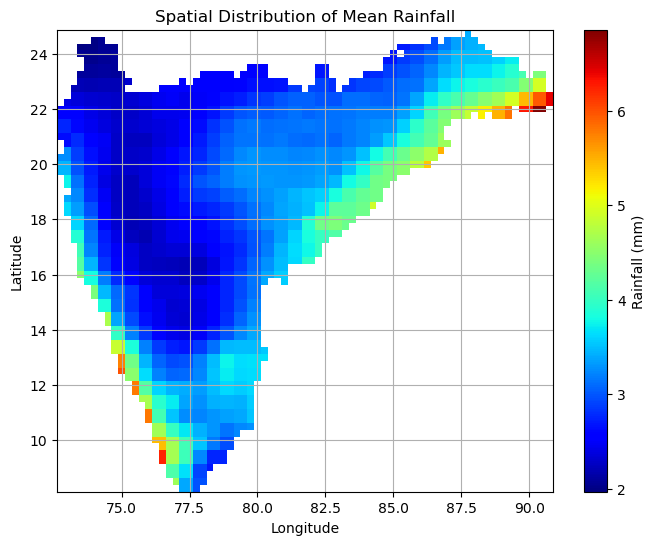

In [64]:
import matplotlib.pyplot as plt
# Compute mean over time (long-term average rainfall)
rain_avg = rain.mean(dim='time')

plt.figure(figsize=(8,6))
rain_avg.plot(cmap='jet',cbar_kwargs={'label': 'Rainfall (mm)'})
plt.title("Spatial Distribution of Mean Rainfall")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)
plt.show()

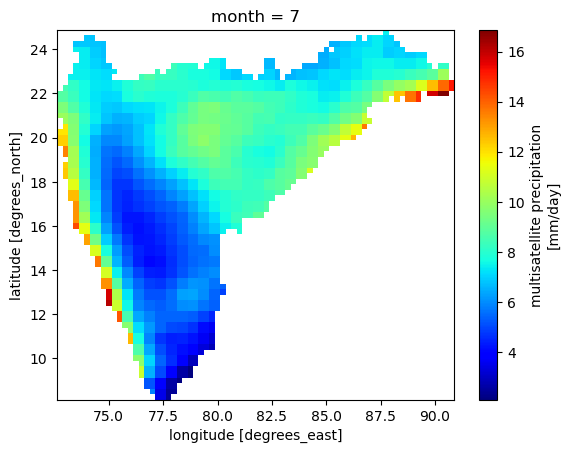

In [65]:
# Average July Rainfall
monthly_avg_map = rain.groupby('time.month').mean()

monthly_avg_map.sel(month=7).plot(cmap='jet')  # July

### Using the precipitation data collected as a part of mini project, compute SPI-3 and SPI-6 for the region of your interest.You can use appropriate probability distribution that would fit your data. Identify drought events if SPI<0. Comment on drought properties such as duration, frequency, intensity and severity of meteorological droughts. Also comment on differences between the droughts identified using SPI-3 and SPI-6.

In [66]:
# monthly Time Series are already prepared in preprocessing step
df.set_index('time', inplace=True) # set index

In [67]:
# rolling sums (SPI Scales)

df['Rain_3'] = df['Rainfall'].rolling(window=3).sum()
df['Rain_6'] = df['Rainfall'].rolling(window=6).sum()

In [68]:
# Fitting Gamma Distribution + SPI

from scipy.stats import gamma, norm

def compute_spi(series):
    original_index = series.index
    valid = series.dropna() # remove NaNs only for fitting
    
    # Gamma distribution Fitting
    shape, loc, scale = gamma.fit(valid, floc=0)
    cdf = gamma.cdf(valid, shape, loc=loc, scale=scale)   # compute CDF
    spi_vals = norm.ppf(cdf) # converting to SPI (standard normal)
    
    # reinsert into full series
    spi_full = pd.Series(index=original_index, dtype=float)
    spi_full.loc[valid.index] = spi_vals
    
    return spi_full

def compute_spi(series):
    original_index = series.index
    valid = series.dropna()

    q = (valid == 0).sum() / len(valid)     # probability of zero rainfall
    valid_nonzero = valid[valid > 0]     # fit gamma only on non-zero values
    shape, loc, scale = gamma.fit(valid_nonzero, floc=0)
    G = gamma.cdf(valid, shape, loc=loc, scale=scale)     # Gamma CDF
    H = q + (1 - q) * G     # adjusted CDF
    spi_vals = norm.ppf(H)     # convert to SPI
    
    spi_full = pd.Series(index=original_index, dtype=float)
    spi_full.loc[valid.index] = spi_vals
    
    return spi_full

In [69]:
# compute SPI 3months and SPI 6months

df['SPI_3'] = compute_spi(df['Rain_3'])
df['SPI_6'] = compute_spi(df['Rain_6'])

In [70]:
# removes invalid rows (start + missing end months)
df_clean = df.dropna(subset=['SPI_3', 'SPI_6'])
print("Final usable dataset:", df_clean.shape)

Final usable dataset: (292, 7)


In [71]:
# Identify Drought Events (SPI < 0)

df['Drought_SPI3'] = df['SPI_3'] < 0
df['Drought_SPI6'] = df['SPI_6'] < 0

In [72]:
# Drought Event Analysis

# A Function to extract drought properties
def drought_analysis(spi_series):
    droughts = []
    in_drought = False
    duration = 0
    severity = 0
    
    for val in spi_series:
        if val < 0:
            in_drought = True
            duration += 1
            severity += val
        else:
            if in_drought:
                droughts.append({
                    'duration': duration,
                    'severity': severity,
                    'intensity': severity / duration
                })
                duration = 0
                severity = 0
                in_drought = False
    
    return pd.DataFrame(droughts)

In [73]:
drought_spi3 = drought_analysis(df_clean['SPI_3'])
drought_spi6 = drought_analysis(df_clean['SPI_6'])

In [74]:
# Metric Computation

def print_summary(name, summary):
    print(f"\n{name} Drought Summary")
    print("_" * 30)
    print(f"Frequency      : {summary['Frequency']}")
    print(f"Avg Duration   : {float(summary['Avg Duration']):.2f} months")
    print(f"Max Duration   : {summary['Max Duration']} months")
    print(f"Avg Severity   : {float(summary['Avg Severity']):.2f}")
    print(f"Avg Intensity  : {float(summary['Avg Intensity']):.2f}")

print_summary("SPI-3", summary_spi3)
print_summary("SPI-6", summary_spi6)




SPI-3 Drought Summary
______________________________
Frequency      : 24
Avg Duration   : 6.04 months
Max Duration   : 7 months
Avg Severity   : -5.38
Avg Intensity  : -0.89

SPI-6 Drought Summary
______________________________
Frequency      : 25
Avg Duration   : 5.24 months
Max Duration   : 7 months
Avg Severity   : -5.12
Avg Intensity  : -0.96


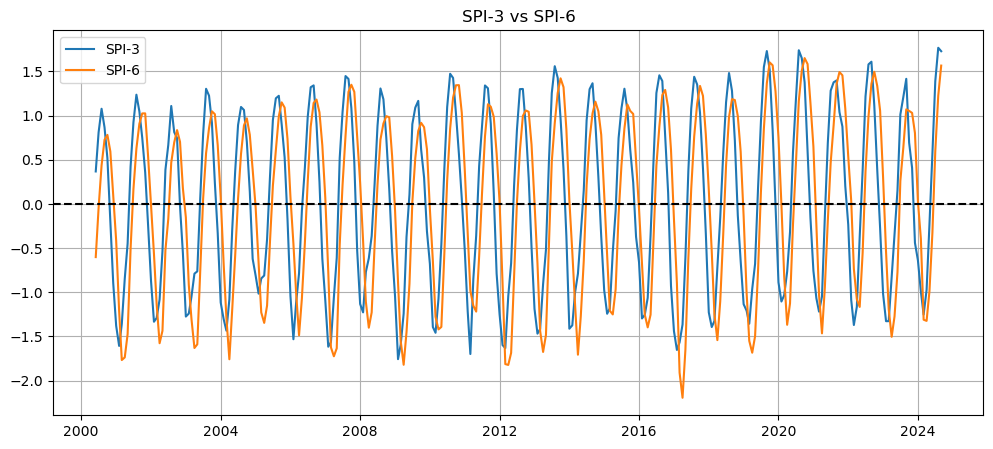

In [75]:
plt.figure(figsize=(12,5))
plt.plot(df_clean.index, df_clean['SPI_3'], label='SPI-3')
plt.plot(df_clean.index, df_clean['SPI_6'], label='SPI-6')

plt.axhline(0, color='black', linestyle='--')
plt.title("SPI-3 vs SPI-6")
plt.legend()
plt.grid()
plt.show()